## Импорты

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold,cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score, classification_report,confusion_matrix, RocCurveDisplay,roc_curve,make_scorer,average_precision_score)
from sklearn.inspection import permutation_importance
from catboost import CatBoostClassifier


## Работа с данными

In [59]:
df = pd.read_csv("./student-por.csv",sep=";")

target = (df['G3'] < 10).astype(int)
X = df.drop(columns="G3")

#one hot encoding
X = pd.get_dummies(X,drop_first=True)

## Графики

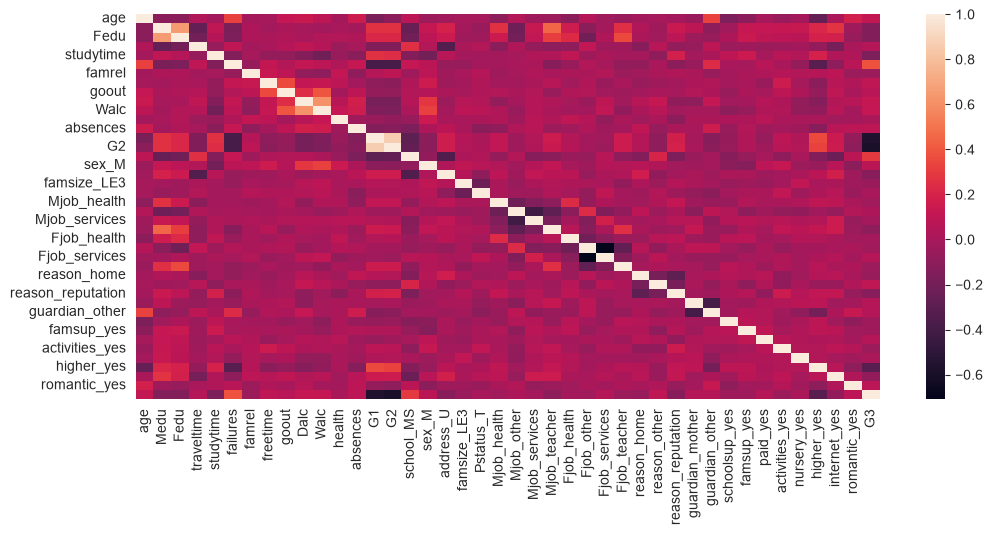

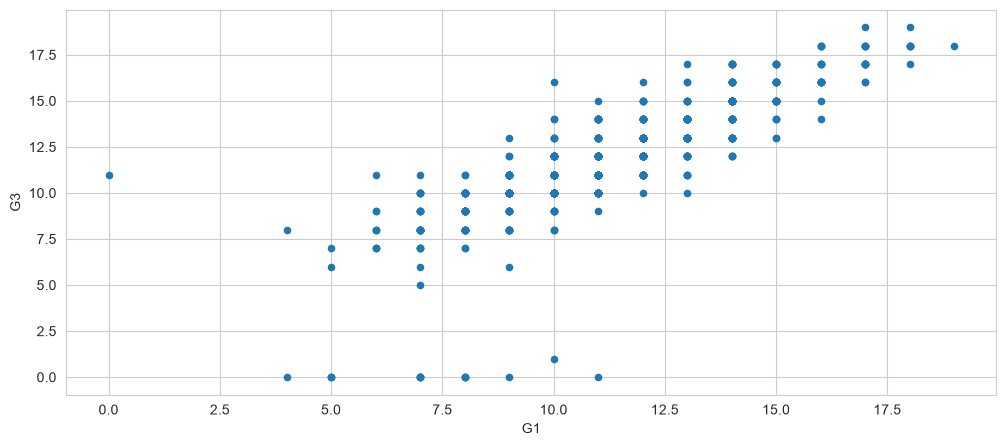

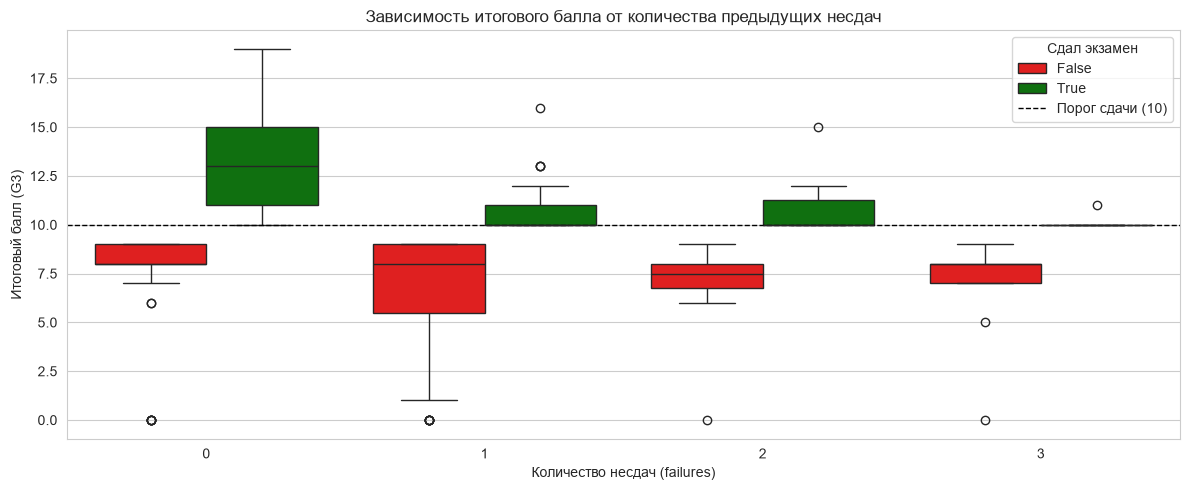

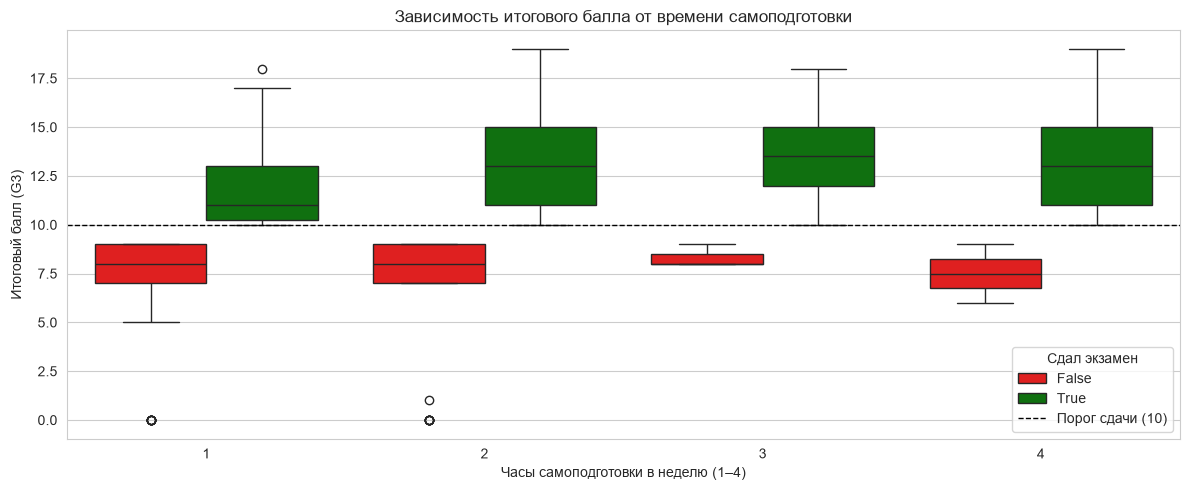

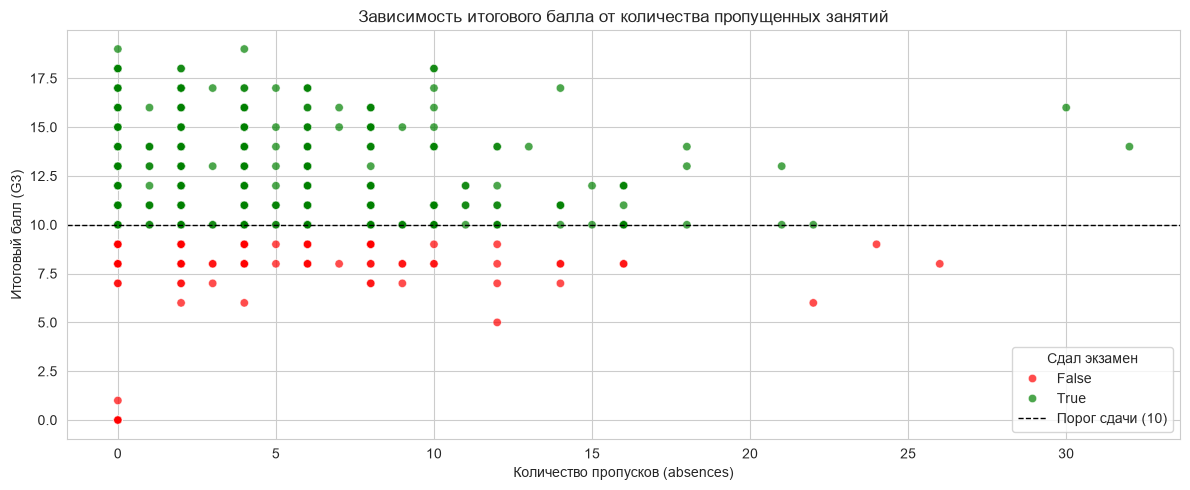

In [ ]:
df['passed'] = df['G3'] >= 10
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

#График 1: температурная карта корреляции
sns.heatmap(X.join(target).corr())

#График 2: зависимость G1 и G2
df.plot.scatter("G1","G3")
plt.show()

#График 3: Зависимость G3 от количества предыдущих несдач
plt.figure()
sns.boxplot(data=df, x='failures', y='G3', hue='passed',
            palette={True: 'green', False: 'red'})
plt.axhline(y=10, color='black', linestyle='--', linewidth=1, label='Порог сдачи (10)')
plt.title('Зависимость итогового балла от количества предыдущих несдач')
plt.xlabel('Количество несдач (failures)')
plt.ylabel('Итоговый балл (G3)')
plt.legend(title='Сдал экзамен')
plt.tight_layout()
plt.show()

#График 4: Зависимость G3 от времени самоподготовки
plt.figure()
sns.boxplot(data=df, x='studytime', y='G3', hue='passed',
            palette={True: 'green', False: 'red'})
plt.axhline(y=10, color='black', linestyle='--', linewidth=1, label='Порог сдачи (10)')
plt.title('Зависимость итогового балла от времени самоподготовки')
plt.xlabel('Часы самоподготовки в неделю (1–4)')
plt.ylabel('Итоговый балл (G3)')
plt.legend(title='Сдал экзамен')
plt.tight_layout()
plt.show()

#График 5: Зависимость G3 от количества пропусков
plt.figure()
sns.scatterplot(data=df, x='absences', y='G3', hue='passed',
                palette={True: 'green', False: 'red'}, alpha=0.7)
plt.axhline(y=10, color='black', linestyle='--', linewidth=1, label='Порог сдачи (10)')
plt.title('Зависимость итогового балла от количества пропущенных занятий')
plt.xlabel('Количество пропусков (absences)')
plt.ylabel('Итоговый балл (G3)')
plt.legend(title='Сдал экзамен')
plt.tight_layout()
plt.show()




## Работа с моделями

In [35]:
KNN = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=31))
logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, class_weight='balanced'))
rf = RandomForestClassifier(
    n_estimators=1000,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
)
CB = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.01,
    depth=10,
    loss_function='Logloss',
    eval_metric='AUC',              
    random_seed=42,
    auto_class_weights='Balanced',  
    verbose=0
)

x_train,x_val,y_train,y_val = train_test_split(X,target,test_size=0.15,stratify=target,random_state=42)

rf.fit(x_train,y_train)
logreg.fit(x_train,y_train)
CB.fit(x_train,y_train)
KNN.fit(x_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('kneighborsclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](41,)","['age','Medu','Fedu',...,'higher_yes','internet_yes','romantic_yes']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,41
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## Оценка моделий

In [45]:
scorer = {
    'roc_auc': 'roc_auc',
    'pr_auc': make_scorer(average_precision_score)
}
cv = StratifiedKFold(5,shuffle=True,random_state=42)

for name,model in [("KNN",KNN),("LogisticRegression",logreg),("RandomForest",rf),("GradientBoosting",CB)]:
    results = cross_validate(model, X,target,cv=cv,scoring=scorer)
    print(f"{name}:")
    print(
        f"ROC-AUC: {results['test_roc_auc'].mean():.3f} ± {results['test_roc_auc'].std():.3f}",
        f"PR-AUC:  {results['test_pr_auc'].mean():.3f} ± {results['test_pr_auc'].std():.3f} \n"
        )
    

KNN:
ROC-AUC: 0.902 ± 0.026 PR-AUC:  0.188 ± 0.049 

LogisticRegression:
ROC-AUC: 0.944 ± 0.014 PR-AUC:  0.509 ± 0.042 

RandomForest:
ROC-AUC: 0.969 ± 0.009 PR-AUC:  0.594 ± 0.027 

GradientBoosting:
ROC-AUC: 0.971 ± 0.004 PR-AUC:  0.648 ± 0.027 



Лучший результат на выборке с G1 и G2 показывает градиентный бустинг, поэтому мы будет и дальше его использовать

## Порог

0.43233299052521174
[[77  6]
 [ 2 13]]

              precision    recall  f1-score   support

       зачёт       0.97      0.93      0.95        83
     незачёт       0.68      0.87      0.76        15

    accuracy                           0.92        98
   macro avg       0.83      0.90      0.86        98
weighted avg       0.93      0.92      0.92        98



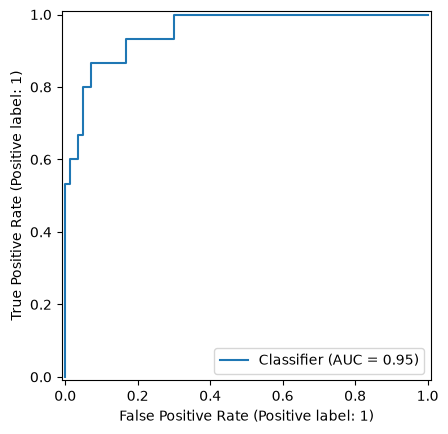

In [48]:
proba = CB.predict_proba(x_val)[:, 1]
threshold = 0.5
Uden_index = []  

#Подбор оптимального порога по индексу Юдена
fpr, tpr, thresholds = roc_curve(y_val, proba)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]
print(optimal_threshold)

pred = (proba >= optimal_threshold).astype(int)
print(confusion_matrix(y_val, pred))
print()
print(classification_report(y_val, pred, target_names=['зачёт', 'незачёт']))

RocCurveDisplay.from_predictions(y_val, proba)
plt.show()


## Три главных фактора

ТОП-3 фактора:
  1. G2                   падение ROC-AUC при перемешивании: 0.1436
  2. G1                   падение ROC-AUC при перемешивании: 0.0508
  3. famrel               падение ROC-AUC при перемешивании: 0.0120


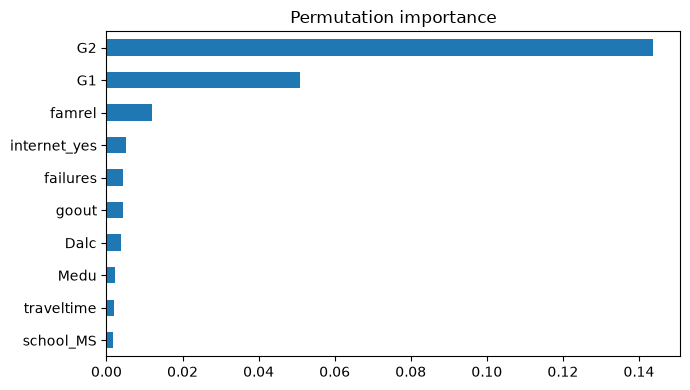

Сильнее всего СНИЖАЮТ риск незачёта:
G2               -3.867
G1               -2.477
age              -0.781
activities_yes   -0.347
Mjob_teacher     -0.270
dtype: float64

Сильнее всего ПОВЫШАЮТ риск незачёта:
Mjob_health        0.287
failures           0.452
Fjob_other         0.522
guardian_mother    0.550
school_MS          0.681
dtype: float64


In [49]:
r = permutation_importance(CB, x_val, y_val, n_repeats=30, random_state=42, scoring='roc_auc')
imp = pd.Series(r.importances_mean, index=X.columns).sort_values(ascending=False)

print('ТОП-3 фактора:')
for i, (name, val) in enumerate(imp.head(3).items(), 1):
    print(f'  {i}. {name:20s} падение ROC-AUC при перемешивании: {val:.4f}')

top = imp.head(10)[::-1]
top.plot(kind='barh', figsize=(7, 4))
plt.title('Permutation importance'); plt.tight_layout(); plt.show()

coefs = pd.Series(logreg.named_steps['logisticregression'].coef_[0], index=X.columns).sort_values()
print('Сильнее всего СНИЖАЮТ риск незачёта:'); print(coefs.head(5).round(3))
print('\nСильнее всего ПОВЫШАЮТ риск незачёта:'); print(coefs.tail(5).round(3))

## Сложный уровень

In [ ]:
X2 = X.drop(columns=['G1', 'G2'])
s = cross_val_score(rf, X2, target, cv=cv, scoring='roc_auc')
s_pr = cross_val_score(rf, X2, target, cv=cv, scoring=make_scorer(average_precision_score))
print(f'без G1 и G2:\n ROC-AUC {s.mean():.3f} +- {s.std():.3f}\n PR-AUC {s_pr.mean():.3f} +- {s_pr.std():.3f}')

X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, target, test_size=.25, stratify=target, random_state=42)
rf2 = RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=42).fit(X2_tr, y2_tr)
r2 = permutation_importance(rf2, X2_te, y2_te, n_repeats=30, random_state=42, scoring='roc_auc')
print()
print(pd.Series(r2.importances_mean, index=X2.columns).sort_values(ascending=False).head(5).round(4).to_string())

без G1 и G2:
 ROC-AUC 0.829 +- 0.029
 PR-AUK 0.333 +- 0.053

school_MS          0.0724
failures           0.0522
higher_yes         0.0368
guardian_mother    0.0095
Mjob_health        0.0040


## Бонус

In [29]:
mat_df = pd.read_csv("student-mat.csv",sep=";")

mat_target = (mat_df['G3'] < 10).astype(int)
mat_df = mat_df.drop(columns="G3")
mat_df = pd.get_dummies(mat_df,drop_first=True)

# 1. Модель со всеми признаками (включая G1 и G2)
rf_full = RandomForestClassifier(
    n_estimators=400, class_weight='balanced', random_state=42
)

rf_full.fit(X, target)
auc_full_transfer = roc_auc_score(mat_target, rf_full.predict_proba(mat_df)[:, 1])
print(f'Полная модель: ROC-AUC на математике = {auc_full_transfer:.3f}')

# 2. Модель без G1 и G2
cols_without_g1g2 = [c for c in X.columns if c not in ['G1', 'G2']]
por_complex = X[cols_without_g1g2]
mat_complex = mat_df[cols_without_g1g2]

rf_complex = RandomForestClassifier(
    n_estimators=400, class_weight='balanced', random_state=42
)
rf_complex.fit(por_complex, target)
auc_complex_transfer = roc_auc_score(mat_target, rf_complex.predict_proba(mat_complex)[:, 1])
print(f'Модель без G1/G2: ROC-AUC на математике = {auc_complex_transfer:.3f}')

# Качество обеих моделей на самом португальском (отложенная выборка)
X_tr_full, X_te_full, y_tr_full, y_te_full = train_test_split(
    X, target, test_size=0.25, stratify=target, random_state=42
)
rf_full_cv = RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=42)
rf_full_cv.fit(X_tr_full, y_tr_full)
auc_full_por = roc_auc_score(y_te_full, rf_full_cv.predict_proba(X_te_full)[:, 1])

X_tr_complex, X_te_complex, y_tr_complex, y_te_complex = train_test_split(
    por_complex, target, test_size=0.25, stratify=target, random_state=42
)
rf_complex_cv = RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=42)
rf_complex_cv.fit(X_tr_complex, y_tr_complex)
auc_complex_por = roc_auc_score(y_te_complex, rf_complex_cv.predict_proba(X_te_complex)[:, 1])

print(f'\nСравнение AUC:')
print(f'  Полная модель:      Португальский (отлож.) = {auc_full_por:.3f}, Математика = {auc_full_transfer:.3f}')
print(f'  Без G1 и G2:        Португальский (отлож.) = {auc_complex_por:.3f}, Математика = {auc_complex_transfer:.3f}')

Полная модель: ROC-AUC на математике = 0.955
Модель без G1/G2: ROC-AUC на математике = 0.645

Сравнение AUC:
  Полная модель:      Португальский (отлож.) = 0.946, Математика = 0.955
  Без G1 и G2:        Португальский (отлож.) = 0.791, Математика = 0.645


Перенос модели, обученной на португальском языке, на математику показывает, что без оценок за текущий период (G1 и G2) качество предсказания заметно снижается (ROC-AUC). Это указывает на то, что личные признаки студента оказывают разное влияние на успеваемость по разным предметам, и универсальной модели "студента вообще" на их основе построить нельзя. Однако полная модель, включающая промежуточные оценки по предмету, почти полностью сохраняет точность, так как эти оценки отражают и общий академический потенциал учащегося. Таким образом, выявленные ранее "три главных фактора" в значительной степени привязаны к конкретному предмету, но не полностью лишены общей составляющей.